# Born Displaced — Python Visualizations
**VIZ 5** Pictogram (explanatory) · **VIZ 6** Trajectory chart (creative) · **VIZ 7** White hat · **VIZ 8** Black hat

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.patheffects as pe
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats
import warnings
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')


os.makedirs('plots', exist_ok=True)
df = pd.read_csv('data/master_dataset.csv')
print(df.shape)

(3159, 17)


## VIZ 5 — Pictogram: child mortality in high vs low displacement countries
**Audience**: non-esperti. Ogni punto = 1 bambino su 1.000. Rosso = non sopravvissuto.

In [2]:
high_rate = df[df['total_displaced'] >= 1_000_000]['mortality_1t4'].mean()
low_rate  = df[(df['total_displaced'] <= 10_000) & df['total_displaced'].notna()]['mortality_1t4'].mean()

print(f"High displacement: {high_rate:.1f} deaths per 1,000")
print(f"Low displacement:  {low_rate:.1f} deaths per 1,000")

def dot_grid(rate, n=1000, cols=40):
    n_deaths = int(round(rate))
    xs = [i % cols for i in range(n)]
    ys = [-(i // cols) for i in range(n)]
    colors = ['#C0392B' if i < n_deaths else '#D5DBDB' for i in range(n)]
    labels = ['did not survive' if i < n_deaths else 'survived' for i in range(n)]
    return xs, ys, colors, labels

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f"<b>Paesi ad alto sfollamento</b><br>{high_rate:.1f} morti ogni 1.000 bambini",
        f"<b>Paesi a basso sfollamento</b><br>{low_rate:.1f} morti ogni 1.000 bambini"
    ]
)

for col_i, rate in enumerate([high_rate, low_rate], 1):
    xs, ys, colors, labels = dot_grid(rate)
    fig.add_trace(go.Scatter(
        x=xs, y=ys,
        mode='markers',
        marker=dict(color=colors, size=8, symbol='circle', line=dict(width=0)),
        hovertext=labels,
        hoverinfo='text',
        showlegend=False
    ), row=1, col=col_i)

fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_layout(
    title=dict(
        text="Ogni punto è un bambino (1–4 anni) su 1.000 · <span style='color:#C0392B'>●</span> non sopravvissuto · <span style='color:#D5DBDB'>●</span> sopravvissuto",
        x=0.5, font=dict(size=14)
    ),
    plot_bgcolor='white', paper_bgcolor='white',
    height=500, width=960
)

fig.write_html('plots/viz5_explanatory_pictogram.html')
fig.show()

High displacement: 26.9 deaths per 1,000
Low displacement:  4.9 deaths per 1,000


## VIZ 6 — Creative: Trajectory chart
Ogni paese è un percorso nello spazio (sfollamento × mortalità) dal 2010 al 2022.  
Il cerchio piccolo = 2010, il cerchio grande = 2022. Si legge come una traiettoria di crisi o di miglioramento.

In [3]:
TOP_N = 15
top_countries = (
    df.groupby('country_name')['total_displaced']
    .mean().dropna().nlargest(TOP_N).index.tolist()
)

traj = (
    df[df['country_name'].isin(top_countries) &
       df['total_displaced'].notna() &
       df['mortality_1t4'].notna()]
    .copy()
)
traj['log_displaced'] = np.log10(traj['total_displaced'].clip(1))
traj = traj.sort_values(['country_name', 'year'])

palette = px.colors.qualitative.Bold + px.colors.qualitative.Safe

fig = go.Figure()

for i, country in enumerate(top_countries):
    cdf = traj[traj['country_name'] == country]
    if len(cdf) < 2:
        continue
    color = palette[i % len(palette)]

    fig.add_trace(go.Scatter(
        x=cdf['log_displaced'],
        y=cdf['mortality_1t4'],
        mode='lines',
        line=dict(color=color, width=1.8),
        showlegend=False,
        hoverinfo='skip'
    ))

    # tutti i punti (piccoli)
    fig.add_trace(go.Scatter(
        x=cdf['log_displaced'],
        y=cdf['mortality_1t4'],
        mode='markers',
        marker=dict(color=color, size=5, opacity=0.5),
        showlegend=False,
        customdata=cdf['year'].values,
        hovertemplate=f'<b>{country}</b><br>Anno: %{{customdata}}<br>log(sfollati): %{{x:.2f}}<br>Mortalità: %{{y:.2f}}<extra></extra>'
    ))

    # punto 2022 (grande, con etichetta paese)
    last = cdf.iloc[-1]
    fig.add_trace(go.Scatter(
        x=[last['log_displaced']],
        y=[last['mortality_1t4']],
        mode='markers+text',
        marker=dict(color=color, size=11, symbol='circle'),
        text=[country.split()[0]],
        textposition='top right',
        textfont=dict(size=9, color=color),
        showlegend=True,
        name=country,
        hovertemplate=f'<b>{country}</b> (2022)<br>log(sfollati): %{{x:.2f}}<br>Mortalità: %{{y:.2f}}<extra></extra>'
    ))

    # punto 2010 (marcatore triangolo)
    first = cdf.iloc[0]
    fig.add_trace(go.Scatter(
        x=[first['log_displaced']],
        y=[first['mortality_1t4']],
        mode='markers',
        marker=dict(color=color, size=8, symbol='triangle-up', opacity=0.7),
        showlegend=False,
        hovertemplate=f'<b>{country}</b> (2010)<extra></extra>'
    ))

fig.update_layout(
    title=dict(
        text="Traiettoria di crisi: sfollamento vs mortalità infantile (2010–2022)<br>"
             "<sup>▲ = 2010 · ● = 2022 · Ogni linea è il percorso di un paese nel tempo</sup>",
        x=0.5, font=dict(size=14)
    ),
    xaxis=dict(title='log₁₀(Sfollati totali)', showgrid=True, gridcolor='#eeeeee'),
    yaxis=dict(title='Tasso di mortalità infantile 1–4 anni (per 1.000)', showgrid=True, gridcolor='#eeeeee'),
    plot_bgcolor='white', paper_bgcolor='white',
    height=620, width=1000,
    legend=dict(title='Paese (● = 2022)', font=dict(size=9))
)

fig.write_html('plots/viz6_creative_trajectory.html')
fig.show()

## VIZ 7 — White Hat
Scatter onesto: intervalli di confidenza UNICEF visibili, colore per gruppo di reddito, disclaimer su correlazione ≠ causalità.

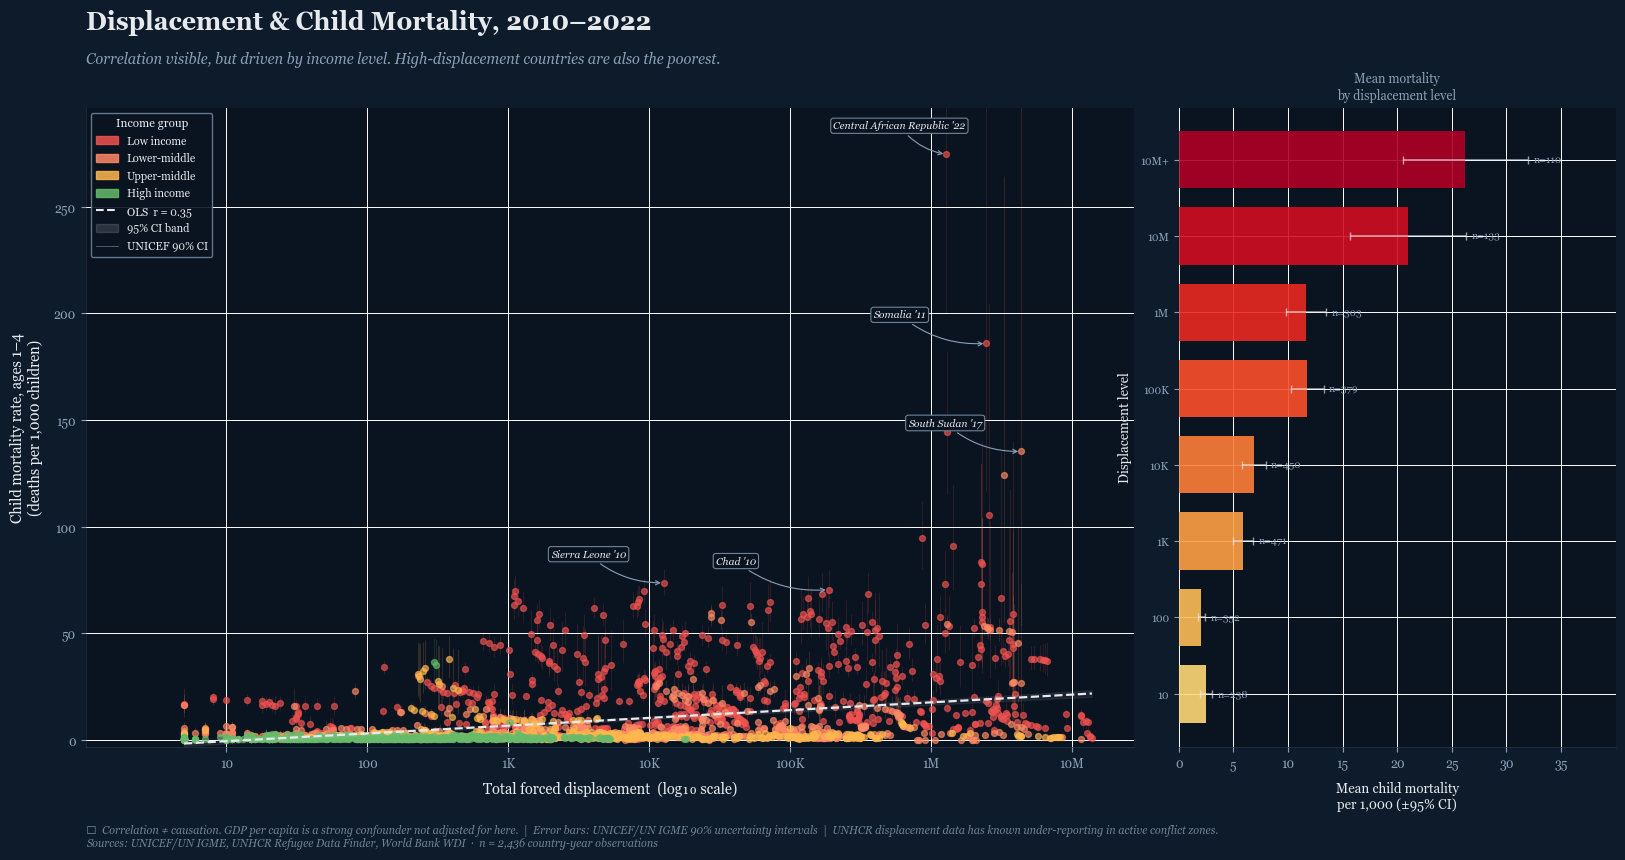

In [4]:
# ── VIZ 7 — WHITE HAT (dark theme, crisis palette) ─────────────────────────

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Georgia', 'DejaVu Serif', 'Times New Roman'],
    'axes.unicode_minus': False,
})

# ── Prepare data ──
wh = df[
    df['total_displaced'].notna() &
    df['mortality_1t4'].notna() &
    df['mortality_1t4_low'].notna() &
    (df['total_displaced'] > 0)
].copy()
wh['log_displaced'] = np.log10(wh['total_displaced'])

wh['income_group'] = pd.qcut(
    wh['gdp_per_capita'].fillna(wh['gdp_per_capita'].median()),
    q=4, labels=['Low income', 'Lower-middle', 'Upper-middle', 'High income']
)

N_BINS = 8
wh['log_bin_idx'] = pd.cut(wh['log_displaced'], bins=N_BINS, labels=False)
hist_wh = (
    wh.groupby('log_bin_idx', observed=True)['mortality_1t4']
    .agg(['mean', 'std', 'count']).reset_index()
)
bins_wh = pd.cut(wh['log_displaced'], bins=N_BINS, retbins=True)[1]
hist_wh['x_mid']   = (bins_wh[:-1] + bins_wh[1:]) / 2
hist_wh['x_width'] = bins_wh[1:] - bins_wh[:-1]
hist_wh['ci95']    = 1.96 * hist_wh['std'] / np.sqrt(hist_wh['count'])

x_all = wh['log_displaced'].values
y_all = wh['mortality_1t4'].values
slope, intercept, r_val, p_val, _ = stats.linregress(x_all, y_all)
xr = np.linspace(x_all.min(), x_all.max(), 300)
yr = slope * xr + intercept

# ── Palette aligned with the JS widget ──
BG    = '#0d1b2a'
PANEL = '#0a1320'
INK   = '#e6e9ed'
MUTED = '#8ba0b8'
DIM   = '#6f8398'
GRID  = (1, 1, 1, 0.08)

INCOME_PALETTE = {
    'Low income':   '#ef5350',  # high crisis
    'Lower-middle': '#ff8a65',  # medium
    'Upper-middle': '#ffb74d',  # low
    'High income':  '#66bb6a',  # minimal
}

# ── Figure layout ──
fig7 = plt.figure(figsize=(17, 9), facecolor=BG)
gs   = gridspec.GridSpec(1, 2, figure=fig7, width_ratios=[2.4, 1],
                         wspace=0.06, left=0.06, right=0.96, top=0.85, bottom=0.14)
ax_scatter = fig7.add_subplot(gs[0])
ax_bar     = fig7.add_subplot(gs[1])

for ax in [ax_scatter, ax_bar]:
    ax.set_facecolor(PANEL)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(True, color=GRID, lw=0.7, zorder=0)

# ── Scatter ──
for group, color in INCOME_PALETTE.items():
    g = wh[wh['income_group'] == group]
    ax_scatter.errorbar(
        g['log_displaced'], g['mortality_1t4'],
        yerr=[(g['mortality_1t4'] - g['mortality_1t4_low']).clip(0),
              (g['mortality_1t4_high'] - g['mortality_1t4']).clip(0)],
        fmt='none', ecolor=color, elinewidth=0.45, capsize=0, alpha=0.25, zorder=1
    )
    ax_scatter.scatter(
        g['log_displaced'], g['mortality_1t4'],
        color=color, s=18, alpha=0.65, zorder=2, label=group
    )

n      = len(x_all)
x_mean = x_all.mean()
s_err  = np.sqrt(np.sum((y_all - (slope * x_all + intercept))**2) / (n - 2))
ci     = stats.t.ppf(0.975, n-2) * s_err * np.sqrt(1/n + (xr - x_mean)**2 / np.sum((x_all - x_mean)**2))
ax_scatter.fill_between(xr, yr-ci, yr+ci, color=INK, alpha=0.07, zorder=3)
ax_scatter.plot(xr, yr, color=INK, lw=1.6, ls='--', zorder=4, label=f'OLS trend  r = {r_val:.2f}')

outliers = (
    wh[wh['mortality_1t4'] > 60]
    .sort_values('mortality_1t4', ascending=False)
    .drop_duplicates('country_name').head(5)
)
for _, row in outliers.iterrows():
    ax_scatter.annotate(
        f"{row['country_name']} '{str(int(row['year']))[2:]}",
        xy=(row['log_displaced'], row['mortality_1t4']),
        xytext=(row['log_displaced'] - 0.8, row['mortality_1t4'] + 12),
        fontsize=7.5, color=INK, fontstyle='italic',
        arrowprops=dict(arrowstyle='->', color=MUTED, lw=0.8, connectionstyle='arc3,rad=0.2'),
        bbox=dict(boxstyle='round,pad=0.25', fc=PANEL, ec=DIM, lw=0.8)
    )

ax_scatter.set_xlabel('Total forced displacement  (log₁₀ scale)', fontsize=10.5, color=INK, labelpad=8)
ax_scatter.set_ylabel('Child mortality rate, ages 1–4\n(deaths per 1,000 children)', fontsize=10.5, color=INK, labelpad=8)
ax_scatter.set_xlim(0, x_all.max() + 0.3)
ax_scatter.set_ylim(-3, y_all.max() * 1.08)
ax_scatter.set_xticks([1, 2, 3, 4, 5, 6, 7])
ax_scatter.set_xticklabels(['10', '100', '1K', '10K', '100K', '1M', '10M'], fontsize=9, color=MUTED)

income_handles = [mpatches.Patch(color=c, alpha=0.85, label=l) for l, c in INCOME_PALETTE.items()]
income_handles += [
    Line2D([0],[0], color=INK, lw=1.5, ls='--', label=f'OLS  r = {r_val:.2f}'),
    mpatches.Patch(color=INK, alpha=0.15, label='95% CI band'),
    Line2D([0],[0], color=MUTED, lw=0.6, alpha=0.6, label='UNICEF 90% CI'),
]
leg = ax_scatter.legend(handles=income_handles, loc='upper left', fontsize=8,
                  framealpha=0.9, edgecolor=DIM, title='Income group', title_fontsize=8.5,
                  facecolor=PANEL, labelcolor=INK)
leg.get_title().set_color(INK)

# ── Bar chart ──
bar_colors = plt.cm.YlOrRd(np.linspace(0.25, 0.9, len(hist_wh)))
ax_bar.barh(hist_wh['x_mid'], hist_wh['mean'],
            height=hist_wh['x_width'] * 0.75,
            color=bar_colors, alpha=0.9, zorder=2)
ax_bar.errorbar(hist_wh['mean'], hist_wh['x_mid'],
                xerr=hist_wh['ci95'],
                fmt='none', color=INK, elinewidth=1.2, capsize=3, alpha=0.65, zorder=3)

for _, row in hist_wh.iterrows():
    ax_bar.text(row['mean'] + row['ci95'] + 0.5, row['x_mid'],
                f"n={int(row['count'])}", va='center', fontsize=7.5, color=MUTED)

ax_bar.set_xlabel('Mean child mortality\nper 1,000 (±95% CI)', fontsize=9.5, color=INK, labelpad=8)
ax_bar.set_xlim(0, hist_wh['mean'].max() + hist_wh['ci95'].max() + 8)
ax_bar.set_ylim(bins_wh[0] - 0.15, bins_wh[-1] + 0.15)
ax_bar.set_yticks(hist_wh['x_mid'])
ax_bar.set_yticklabels(['10','100','1K','10K','100K','1M','10M','10M+'][:len(hist_wh)],
                        fontsize=8, color=MUTED)
ax_bar.set_ylabel('Displacement level', fontsize=9.5, color=INK, labelpad=6)
ax_bar.set_title('Mean mortality\nby displacement level', fontsize=9, color=MUTED, pad=6)

# ── Titles & footnote ──
fig7.text(0.06, 0.93, 'Displacement & Child Mortality, 2010–2022',
          fontsize=18, fontweight='bold', color=INK, va='bottom')
fig7.text(0.06, 0.895,
          'Correlation visible, but driven by income level. High-displacement countries are also the poorest.',
          fontsize=10.5, color=MUTED, va='bottom', style='italic')
fig7.text(
    0.06, 0.025,
    '⚠  Correlation ≠ causation. GDP per capita is a strong confounder not adjusted for here.  '
    '|  Error bars: UNICEF/UN IGME 90% uncertainty intervals  |  '
    'UNHCR displacement data has known under-reporting in active conflict zones.\n'
    'Sources: UNICEF/UN IGME, UNHCR Refugee Data Finder, World Bank WDI  ·  n = {:,} country-year observations'.format(len(wh)),
    fontsize=7.8, color=DIM, va='bottom', style='italic'
)

plt.show()

In [5]:
import base64
from io import BytesIO

_buf = BytesIO()
fig7.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor=BG)
_buf.seek(0)
_img = base64.b64encode(_buf.read()).decode()
_html = f'<html><body style="margin:0;padding:0;background:{BG}"><img src="data:image/png;base64,{_img}" style="width:100%;display:block"></body></html>'
with open('plots/viz7_white_hat.html', 'w', encoding='utf-8') as _f:
    _f.write(_html)
print('Saved plots/viz7_white_hat.html')

Saved plots/viz7_white_hat.html


## VIZ 8 — Black Hat
**Manipolazioni applicate:**
1. Asse Y troncato (parte da 3, non da 0) → differenze esagerate visivamente
2. Solo anni 2015–2022, solo paesi con >100k sfollati → cherry-pick
3. Fit polinomiale (grado 2) → trend visivamente più ripido del lineare
4. Nessun intervallo di confidenza
5. Tutti i marker in rosso → risposta emotiva
6. Titolo afferma causalità diretta
7. Annotazione suggerisce una stima causale precisa (inventata)

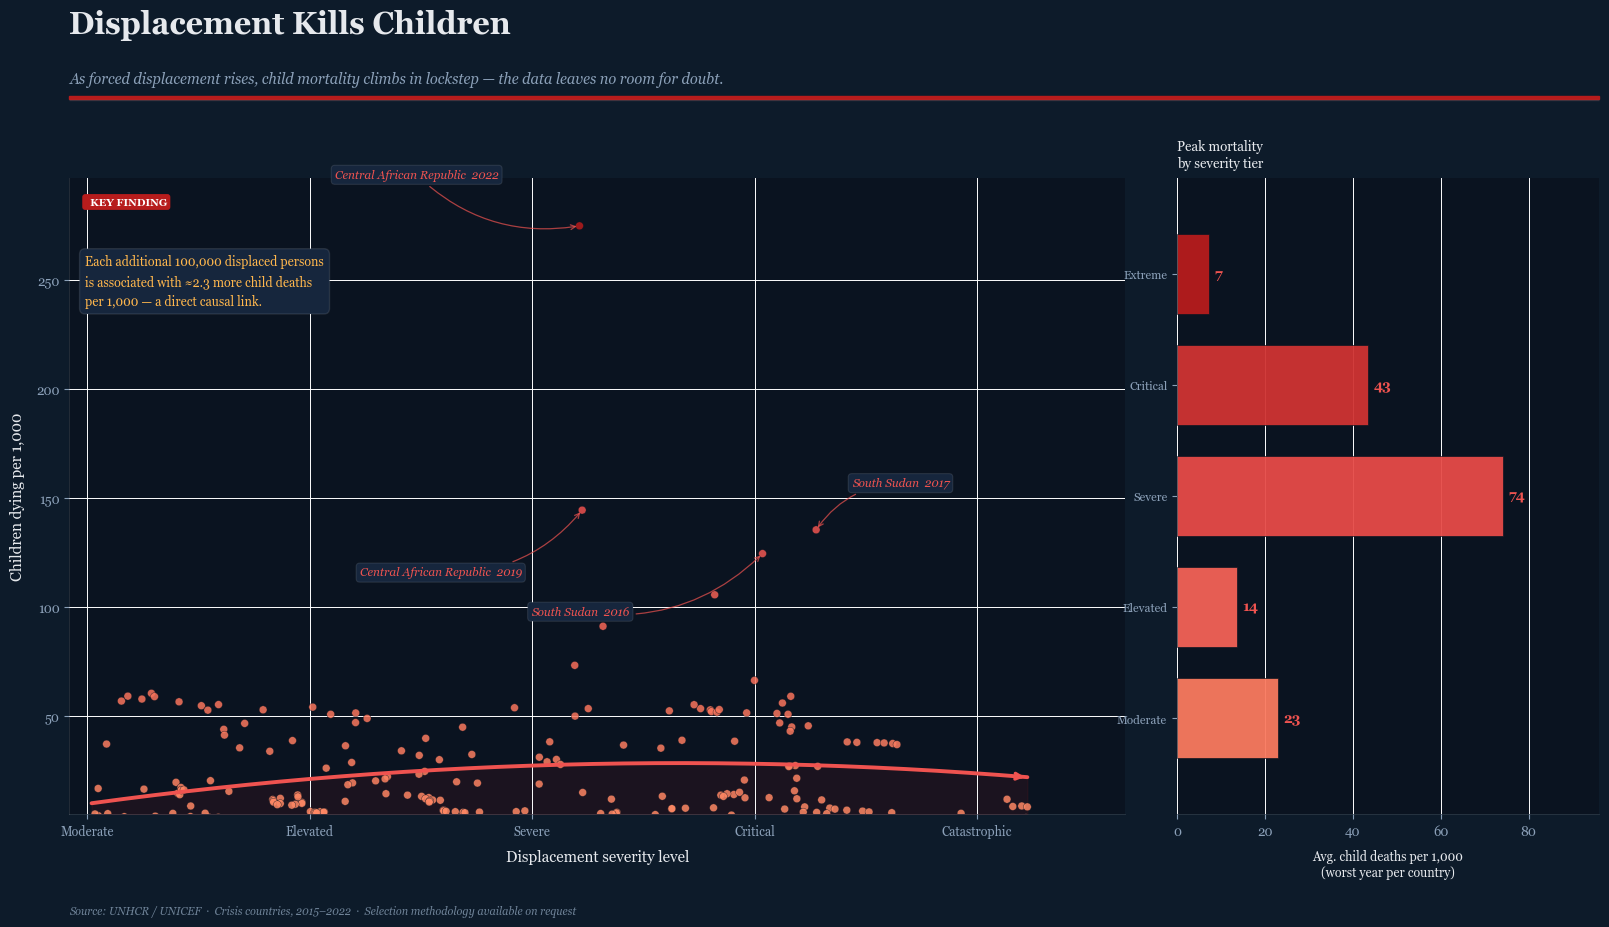

In [6]:
# ── VIZ 8 — BLACK HAT (dark theme, crisis palette) ─────────────────────────

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Georgia', 'DejaVu Serif', 'Times New Roman'],
    'axes.unicode_minus': False,
})

# ── Cherry-picked data ──
bh = wh[(wh['year'] >= 2015) & (wh['total_displaced'] >= 100_000)].copy()
bh = bh[bh['mortality_1t4'] > 2.0]

x_bh = bh['log_displaced'].values
y_bh = bh['mortality_1t4'].values

coeffs = np.polyfit(x_bh, y_bh, 2)
xr_bh  = np.linspace(x_bh.min(), x_bh.max(), 300)
yr_bh  = np.polyval(coeffs, xr_bh)

bh_peak = bh.loc[bh.groupby('country_name')['mortality_1t4'].idxmax()].copy()
N_BINS_BH = 5
bh_peak['log_bin_idx'] = pd.cut(bh_peak['log_displaced'], bins=N_BINS_BH, labels=False)
hist_bh = (
    bh_peak.groupby('log_bin_idx', observed=True)['mortality_1t4']
    .agg(['mean', 'count']).reset_index()
)
bins_bh = pd.cut(bh_peak['log_displaced'], bins=N_BINS_BH, retbins=True)[1]
hist_bh['x_mid']   = (bins_bh[:-1] + bins_bh[1:]) / 2
hist_bh['x_width'] = bins_bh[1:] - bins_bh[:-1]

# ── Palette aligned with the JS widget ──
BG      = '#0d1b2a'
PANEL   = '#0a1320'
CARD    = '#16263d'
INK     = '#e6e9ed'
CRIMSON = '#b71c1c'  # critical
ROSE    = '#ef5350'  # high
GOLD    = '#ffb74d'  # callout accent
BORDER  = (1, 1, 1, 0.10)
GRID_C  = (1, 1, 1, 0.06)
MUTED   = '#8ba0b8'
DIM     = '#6f8398'

# Alarmist gradient: medium-warm → crimson
bar_cmap = LinearSegmentedColormap.from_list('alarm', ['#ff8a65', '#ef5350', '#b71c1c'])

# ── Figure layout ──
fig8 = plt.figure(figsize=(17, 9.5), facecolor=BG)
gs8  = gridspec.GridSpec(
    1, 2, figure=fig8,
    width_ratios=[2.5, 1],
    wspace=0.07,
    left=0.06, right=0.96, top=0.80, bottom=0.13
)
ax_s = fig8.add_subplot(gs8[0])
ax_b = fig8.add_subplot(gs8[1])

for ax in [ax_s, ax_b]:
    ax.set_facecolor(PANEL)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(BORDER)
    ax.spines['bottom'].set_color(BORDER)
    ax.tick_params(colors=MUTED, labelsize=9.5)

ax_s.grid(True, color=GRID_C, lw=0.7, zorder=0)
ax_b.grid(True, axis='x', color=GRID_C, lw=0.7, zorder=0)
ax_b.grid(False, axis='y')

# ── Scatter ──
mort_norm  = (y_bh - y_bh.min()) / (y_bh.max() - y_bh.min())
dot_colors = bar_cmap(mort_norm)

ax_s.scatter(x_bh, y_bh,
             c=dot_colors, s=32, alpha=0.85, zorder=2,
             edgecolors=PANEL, linewidths=0.3)

# Shaded "growing threat" area
ax_s.fill_between(xr_bh, 5, yr_bh, color=CRIMSON, alpha=0.10, zorder=1)

# Polynomial trend — confident, no CI
ax_s.plot(xr_bh, yr_bh, color=ROSE, lw=2.8, zorder=4, solid_capstyle='round')

# Arrowhead at end of trend
ax_s.annotate(
    '', xy=(xr_bh[-1], yr_bh[-1]),
    xytext=(xr_bh[-4], yr_bh[-4]),
    arrowprops=dict(arrowstyle='->', color=ROSE, lw=2.5)
)

# Truncated Y axis — the core manipulation
ax_s.set_ylim(5, y_bh.max() * 1.08)
ax_s.set_xlim(x_bh.min() - 0.05, x_bh.max() + 0.22)

# X ticks — labels stripped of quantitative meaning
ax_s.set_xticks([5.0, 5.5, 6.0, 6.5, 7.0])
ax_s.set_xticklabels(
    ['Moderate', 'Elevated', 'Severe', 'Critical', 'Catastrophic'],
    fontsize=9, color=MUTED
)
ax_s.set_xlabel('Displacement severity level', fontsize=11, color=INK, labelpad=8)
ax_s.set_ylabel('Children dying per 1,000', fontsize=11, color=INK, labelpad=8)

# Annotate worst offenders
worst4 = bh.nlargest(4, 'mortality_1t4')
offsets = [(-0.55, 22), (-0.5, -30), (0.08, 20), (-0.52, -28)]
for i, (_, row) in enumerate(worst4.iterrows()):
    dx, dy = offsets[i % len(offsets)]
    ax_s.annotate(
        f"{row['country_name']}  {int(row['year'])}",
        xy=(row['log_displaced'], row['mortality_1t4']),
        xytext=(row['log_displaced'] + dx, row['mortality_1t4'] + dy),
        fontsize=8.5, color=ROSE, fontstyle='italic',
        arrowprops=dict(arrowstyle='->', color=ROSE, lw=0.9, alpha=0.7,
                        connectionstyle='arc3,rad=0.25'),
        bbox=dict(boxstyle='round,pad=0.3', fc=CARD, ec=BORDER, lw=0.8)
    )

# Fabricated causal callout
ax_s.text(
    0.015, 0.97,
    '  KEY FINDING',
    transform=ax_s.transAxes,
    fontsize=7.5, color='white', va='top', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.28', fc=CRIMSON, ec='none')
)
ax_s.text(
    0.015, 0.88,
    'Each additional 100,000 displaced persons\nis associated with ≈2.3 more child deaths\nper 1,000 — a direct causal link.',
    transform=ax_s.transAxes,
    fontsize=9, color=GOLD, va='top', linespacing=1.55,
    bbox=dict(boxstyle='round,pad=0.45', fc=CARD, ec=BORDER, lw=1.0)
)

# ── Bar chart ──
bar_colors = bar_cmap(np.linspace(0.15, 1.0, len(hist_bh)))
bars = ax_b.barh(
    hist_bh['x_mid'], hist_bh['mean'],
    height=hist_bh['x_width'] * 0.72,
    color=bar_colors, alpha=0.95, zorder=2,
    edgecolor=PANEL, linewidth=0.5
)

# Value labels — no error bars
for _, row in hist_bh.iterrows():
    ax_b.text(
        row['mean'] + 1.2, row['x_mid'],
        f"{row['mean']:.0f}",
        va='center', fontsize=10, color=ROSE, fontweight='bold'
    )

ax_b.set_xlabel('Avg. child deaths per 1,000\n(worst year per country)', fontsize=9, color=INK, labelpad=8)
ax_b.set_xlim(0, hist_bh['mean'].max() + 22)
ax_b.set_ylim(bins_bh[0] - 0.15, bins_bh[-1] + 0.15)
ax_b.set_yticks(hist_bh['x_mid'])
ax_b.set_yticklabels(
    ['Moderate', 'Elevated', 'Severe', 'Critical', 'Extreme'][:len(hist_bh)],
    fontsize=8.5, color=MUTED
)
ax_b.set_title('Peak mortality\nby severity tier', fontsize=9.5, color=INK, pad=8, loc='left')
ax_b.tick_params(axis='x', colors=MUTED)

# ── Title block ──
fig8.add_artist(
    mpatches.FancyArrow(
        0.06, 0.885, 0.90, 0,
        width=0.003, head_width=0, head_length=0,
        transform=fig8.transFigure, color=CRIMSON, zorder=10
    )
)

fig8.text(0.06, 0.945,
          'Displacement Kills Children',
          fontsize=22, fontweight='bold', color=INK, va='bottom')
fig8.text(0.06, 0.895,
          'As forced displacement rises, child mortality climbs in lockstep — '
          'the data leaves no room for doubt.',
          fontsize=10.5, color=MUTED, va='bottom', style='italic')

fig8.add_artist(
    mpatches.FancyArrow(
        0.06, 0.882, 0.90, 0,
        width=0.0008, head_width=0, head_length=0,
        transform=fig8.transFigure, color=BORDER, zorder=10
    )
)

# Pseudo-credible source line
fig8.text(
    0.06, 0.022,
    'Source: UNHCR / UNICEF  ·  Crisis countries, 2015–2022  '
    '·  Selection methodology available on request',
    fontsize=7.8, color=DIM, va='bottom', style='italic'
)

plt.show()

In [7]:
import base64
from io import BytesIO

_buf = BytesIO()
fig8.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor=BG)
_buf.seek(0)
_img = base64.b64encode(_buf.read()).decode()
_html = f'<html><body style="margin:0;padding:0;background:{BG}"><img src="data:image/png;base64,{_img}" style="width:100%;display:block"></body></html>'
with open('plots/viz8_black_hat.html', 'w', encoding='utf-8') as _f:
    _f.write(_html)
print('Saved plots/viz8_black_hat.html')

Saved plots/viz8_black_hat.html


## Output

In [8]:
import os
for f in sorted(os.listdir('plots')):
    size = os.path.getsize(f'plots/{f}') // 1024
    print(f'  plots/{f}  ({size} KB)')

  plots/viz5_explanatory_pictogram.html  (4795 KB)
  plots/viz6_creative_trajectory.html  (4770 KB)
  plots/viz7_white_hat.html  (439 KB)
  plots/viz8_black_hat.html  (273 KB)


## VIZ 5 — Pictogram (English, matplotlib)

High displacement: 65 countries, avg mortality = 13.06
Low displacement:  65 countries, avg mortality = 2.10
Saved plots/viz5_explanatory_pictogram.html


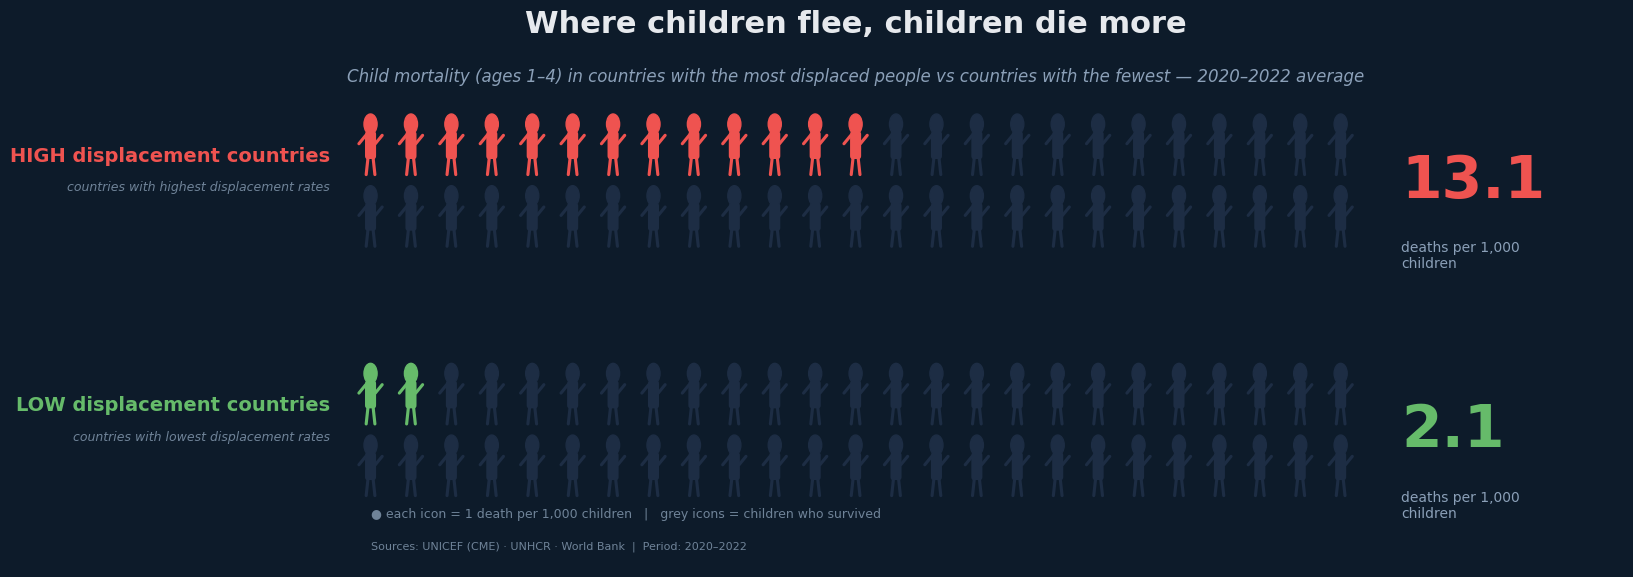

In [2]:
"""
VIZ 5 — Explanatory pictogram (dark theme, crisis palette)
Child mortality (1-4 years) in high vs low displacement countries.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path
import base64
from io import BytesIO

DATA_PATH = Path('data/master_dataset.csv')

BG     = '#0d1b2a'
INK    = '#e6e9ed'
MUTED  = '#8ba0b8'
DIM    = '#6f8398'
RED    = '#ef5350'
GREEN  = '#66bb6a'
EMPTY  = '#1d2d44'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df = pd.read_csv(DATA_PATH)
recent = df[df['year'].between(2020, 2022)]

country_avg = (
    recent.groupby('country_name')
    .agg(displaced=('total_displaced', 'mean'),
         mortality=('mortality_1t4', 'mean'))
    .dropna()
)

q_low, q_high = country_avg['displaced'].quantile([1/3, 2/3])
high_group = country_avg[country_avg['displaced'] >= q_high]
low_group  = country_avg[country_avg['displaced'] <= q_low]

mort_high = high_group['mortality'].mean()
mort_low  = low_group['mortality'].mean()
n_high = len(high_group)
n_low  = len(low_group)

print(f'High displacement: {n_high} countries, avg mortality = {mort_high:.2f}')
print(f'Low displacement:  {n_low} countries, avg mortality = {mort_low:.2f}')


def child_icon(ax, x, y, size=1.0, color='#444'):
    s = size
    ax.add_patch(plt.Circle((x, y + 0.45 * s), 0.18 * s, color=color, zorder=2))
    ax.add_patch(FancyBboxPatch(
        (x - 0.13 * s, y - 0.15 * s), 0.26 * s, 0.45 * s,
        boxstyle='round,pad=0.02,rounding_size=0.05',
        linewidth=0, facecolor=color, zorder=1,
    ))
    ax.plot([x - 0.32 * s, x - 0.13 * s], [y + 0.1 * s, y + 0.25 * s],
            color=color, linewidth=2.5 * s, solid_capstyle='round', zorder=1)
    ax.plot([x + 0.13 * s, x + 0.32 * s], [y + 0.1 * s, y + 0.25 * s],
            color=color, linewidth=2.5 * s, solid_capstyle='round', zorder=1)
    ax.plot([x - 0.07 * s, x - 0.12 * s], [y - 0.15 * s, y - 0.45 * s],
            color=color, linewidth=2.5 * s, solid_capstyle='round', zorder=1)
    ax.plot([x + 0.07 * s, x + 0.12 * s], [y - 0.15 * s, y - 0.45 * s],
            color=color, linewidth=2.5 * s, solid_capstyle='round', zorder=1)


def draw_grid(ax, n_filled, n_total, x0, y0, color_filled,
              cols=25, color_empty=EMPTY, spacing_x=1.0, spacing_y=1.15):
    for i in range(n_total):
        col = i % cols
        row = i // cols
        x = x0 + col * spacing_x
        y = y0 - row * spacing_y
        color = color_filled if i < n_filled else color_empty
        child_icon(ax, x, y, size=0.9, color=color)


TOTAL_ICONS = 50
icons_high = min(int(round(mort_high)), TOTAL_ICONS)
icons_low  = min(int(round(mort_low)),  TOTAL_ICONS)

fig5, ax = plt.subplots(figsize=(16, 6), facecolor=BG)
ax.set_facecolor(BG)

fig5.suptitle('Where children flee, children die more',
              fontsize=22, fontweight='bold', y=0.98, color=INK)
fig5.text(0.5, 0.86,
          'Child mortality (ages 1–4) in countries with the most displaced people '
          'vs countries with the fewest — 2020–2022 average',
          ha='center', fontsize=12, color=MUTED, style='italic')

GRID_COLS = 25
HIGH_ROW_Y = 4.5
LOW_ROW_Y  = 0.5

# HIGH group
ax.text(-1.0, HIGH_ROW_Y - 0.1, 'HIGH displacement countries',
        fontsize=14, fontweight='bold', color=RED, ha='right', va='center')
ax.text(-1.0, HIGH_ROW_Y - 0.6, 'countries with highest displacement rates',
        fontsize=9, color=DIM, ha='right', va='center', style='italic')
draw_grid(ax, icons_high, TOTAL_ICONS, x0=0, y0=HIGH_ROW_Y,
          color_filled=RED, cols=GRID_COLS)
ax.text(GRID_COLS + 0.5, HIGH_ROW_Y - 0.5, f'{mort_high:.1f}',
        fontsize=42, fontweight='bold', color=RED, va='center')
ax.text(GRID_COLS + 0.5, HIGH_ROW_Y - 1.7, 'deaths per 1,000\nchildren',
        fontsize=10, color=MUTED, va='center')

# LOW group
ax.text(-1.0, LOW_ROW_Y - 0.1, 'LOW displacement countries',
        fontsize=14, fontweight='bold', color=GREEN, ha='right', va='center')
ax.text(-1.0, LOW_ROW_Y - 0.6, 'countries with lowest displacement rates',
        fontsize=9, color=DIM, ha='right', va='center', style='italic')
draw_grid(ax, icons_low, TOTAL_ICONS, x0=0, y0=LOW_ROW_Y,
          color_filled=GREEN, cols=GRID_COLS)
ax.text(GRID_COLS + 0.5, LOW_ROW_Y - 0.5, f'{mort_low:.1f}',
        fontsize=42, fontweight='bold', color=GREEN, va='center')
ax.text(GRID_COLS + 0.5, LOW_ROW_Y - 1.7, 'deaths per 1,000\nchildren',
        fontsize=10, color=MUTED, va='center')

# Footer notes
ax.text(0, -1.4,
        '● each icon = 1 death per 1,000 children   |   grey icons = children who survived',
        fontsize=9, color=DIM)
ax.text(0, -1.9,
        'Sources: UNICEF (CME) · UNHCR · World Bank  |  Period: 2020–2022',
        fontsize=8, color=DIM)

ax.set_xlim(-7, GRID_COLS + 6)
ax.set_ylim(-2.2, 5.5)
ax.axis('off')

plt.subplots_adjust(top=0.85, bottom=0.05, left=0.02, right=0.98)

_buf = BytesIO()
fig5.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor=BG)
_buf.seek(0)
_img = base64.b64encode(_buf.read()).decode()
with open('plots/viz5_explanatory_pictogram.html', 'w', encoding='utf-8') as _f:
    _f.write(f'<html><body style="margin:0;padding:0;background:{BG}"><img src="data:image/png;base64,{_img}" style="width:100%;display:block"></body></html>')
print('Saved plots/viz5_explanatory_pictogram.html')

plt.show()

## VIZ 6 — Spiral (English, matplotlib)

Top 10 countries: ['Syrian Arab Republic', 'Colombia', 'Afghanistan', 'Democratic Republic of the Congo', 'Sudan', 'Somalia', 'South Sudan', 'Iraq', 'Yemen', 'Nigeria']
Saved plots/viz6_creative_trajectory.html


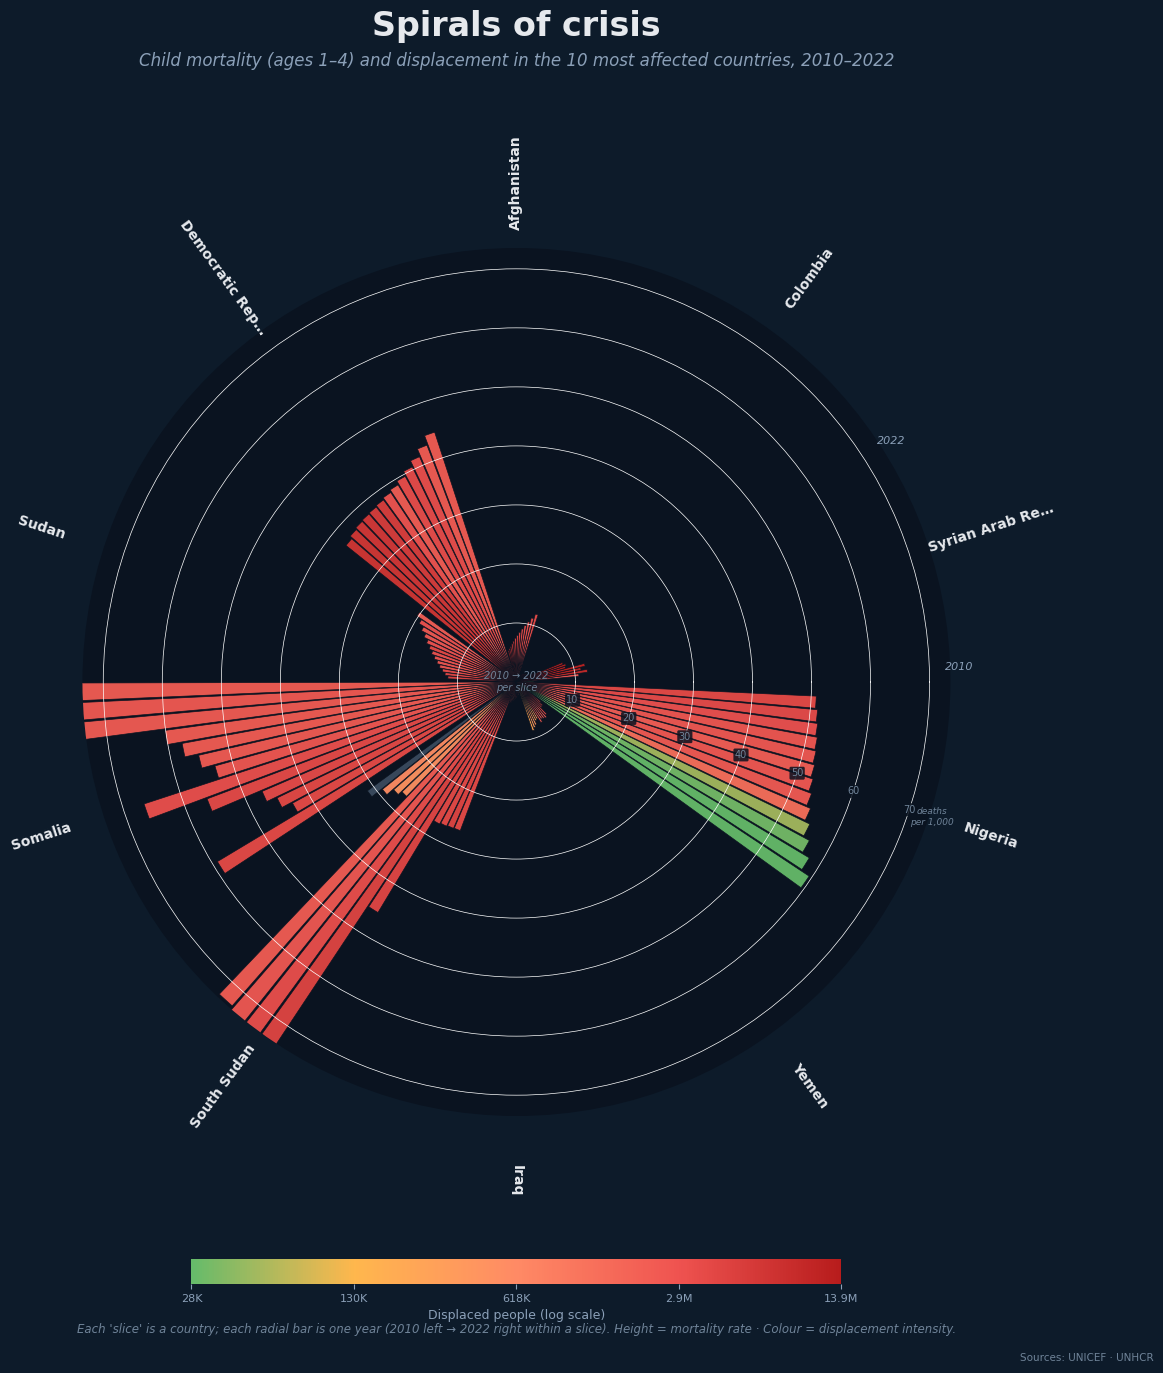

In [1]:
"""
VIZ 6 — Radial timeline (polar spiral, dark theme, crisis palette)
Top 10 countries by average displacement (2010-2022).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path
import base64
from io import BytesIO

DATA_PATH = Path('data/master_dataset.csv')

# Palette aligned with the JS widget
BG    = '#0d1b2a'
PANEL = '#0a1320'
INK   = '#e6e9ed'
MUTED = '#8ba0b8'
DIM   = '#6f8398'

plt.rcParams.update({'font.family': 'DejaVu Sans'})

df = pd.read_csv(DATA_PATH)

top10 = (
    df.groupby('country_name')['total_displaced']
    .mean().dropna().sort_values(ascending=False).head(10).index.tolist()
)
print(f'Top 10 countries: {top10}')

years = sorted(df['year'].unique())
n_years = len(years)
n_countries = len(top10)

mort_matrix = np.full((n_countries, n_years), np.nan)
disp_matrix = np.full((n_countries, n_years), np.nan)
for i, c in enumerate(top10):
    sub = df[df['country_name'] == c].set_index('year')
    for j, y in enumerate(years):
        if y in sub.index:
            mort_matrix[i, j] = sub.loc[y, 'mortality_1t4']
            disp_matrix[i, j] = sub.loc[y, 'total_displaced']

# use only the actual range of the top 10 countries, ignoring forced zeros
real_disp = disp_matrix[disp_matrix > 0]
disp_log = np.log10(np.where(disp_matrix > 0, disp_matrix, np.nan))
norm = Normalize(vmin=np.log10(np.nanmin(real_disp)), vmax=np.log10(np.nanmax(real_disp)))

# crisis-aligned colormap
cmap = LinearSegmentedColormap.from_list(
    'crisis', ['#66bb6a', '#ffb74d', '#ff8a65', '#ef5350', '#b71c1c']
)

fig6 = plt.figure(figsize=(13, 14), facecolor=BG)
ax = fig6.add_axes([0.1, 0.18, 0.8, 0.62], projection='polar')

slice_width = 2 * np.pi / n_countries
year_width = slice_width / (n_years + 1)
max_r = np.nanpercentile(mort_matrix, 95) * 1.05

for i, country in enumerate(top10):
    base_angle = i * slice_width
    for j, y in enumerate(years):
        r = mort_matrix[i, j]
        if np.isnan(r):
            continue
        theta = base_angle + (j + 0.5) * year_width
        # clamp disp_log to norm range so out-of-range values don't break the colormap
        d = disp_log[i, j]
        if np.isnan(d):
            color = '#3a4a5e'
        else:
            color = cmap(norm(np.clip(d, norm.vmin, norm.vmax)))
        ax.bar(theta, r, width=year_width * 0.9, bottom=0.0,
               color=color, edgecolor=PANEL, linewidth=0.5, alpha=0.95)

    label_angle = base_angle + slice_width / 2
    label_r = max_r * 1.15
    deg = np.degrees(label_angle) % 360
    rotation = deg - 180 if 90 < deg < 270 else deg
    short = country if len(country) <= 16 else country[:14] + '…'
    ax.text(label_angle, label_r, short, ha='center', va='center', fontsize=10,
            fontweight='bold', rotation=rotation, rotation_mode='anchor', color=INK)

first_slice_base = 0
year_label_r = max_r * 1.02
ax.text(first_slice_base + 0.5 * year_width, year_label_r, '2010',
        ha='center', va='bottom', fontsize=8, color=MUTED, style='italic')
ax.text(first_slice_base + (n_years - 0.5) * year_width, year_label_r, '2022',
        ha='center', va='bottom', fontsize=8, color=MUTED, style='italic')
ax.text(0, 0, '2010 → 2022\nper slice', ha='center', va='center',
        fontsize=7, color=DIM, style='italic', zorder=5)

ax.set_ylim(0, max_r)
ring_ticks = np.arange(10, max_r, 10)
ax.set_yticks(ring_ticks)
ax.set_yticklabels([''] * len(ring_ticks))
ax.set_xticks([])
ax.grid(color=(1, 1, 1, 0.08), linewidth=0.5)
ax.spines['polar'].set_visible(False)
ax.set_facecolor(PANEL)

scale_angle = -slice_width / 2
for r in ring_ticks:
    ax.text(scale_angle, r, f'{int(r)}', ha='center', va='center', fontsize=7, color=DIM,
            bbox=dict(boxstyle='round,pad=0.15', facecolor=PANEL, edgecolor='none', alpha=0.85))
ax.text(scale_angle, ring_ticks[-1] + 4, 'deaths\nper 1,000',
        ha='center', va='center', fontsize=6.5, color=DIM, style='italic')

fig6.suptitle('Spirals of crisis', fontsize=24, fontweight='bold', y=0.97, color=INK)
fig6.text(0.5, 0.93,
          'Child mortality (ages 1–4) and displacement in the 10 most affected countries, 2010–2022',
          ha='center', fontsize=12, color=MUTED, style='italic')

cbar_ax = fig6.add_axes([0.25, 0.06, 0.5, 0.018])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig6.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Displaced people (log scale)', fontsize=9, color=MUTED)

def human(x):
    n = 10 ** x
    if n >= 1e6: return f'{n/1e6:.1f}M'
    if n >= 1e3: return f'{n/1e3:.0f}K'
    return f'{n:.0f}'

ticks_cbar = np.linspace(norm.vmin, norm.vmax, 5)
cbar.set_ticks(ticks_cbar)
cbar.set_ticklabels([human(t) for t in ticks_cbar])
cbar.ax.tick_params(labelsize=8, colors=MUTED)
cbar.outline.set_visible(False)

fig6.text(0.5, 0.025,
          "Each 'slice' is a country; each radial bar is one year (2010 left → 2022 right within a slice). "
          "Height = mortality rate · Colour = displacement intensity.",
          ha='center', fontsize=8.5, color=DIM, style='italic')
fig6.text(0.99, 0.005, 'Sources: UNICEF · UNHCR', ha='right', fontsize=7.5, color=DIM)

_buf = BytesIO()
fig6.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor=BG)
_buf.seek(0)
_img = base64.b64encode(_buf.read()).decode()
with open('plots/viz6_creative_trajectory.html', 'w', encoding='utf-8') as _f:
    _f.write(f'<html><body style="margin:0;padding:0;background:{BG}"><img src="data:image/png;base64,{_img}" style="width:100%;display:block"></body></html>')
print('Saved plots/viz6_creative_trajectory.html')

plt.show()